# Workshop - 5 (  License Plate Detection using OpenCV and Haar Cascade Classifier )
# Name : JISHNUPRIYAN S
# Reg No : 212223240061 

Detected: 2
Final plates: 2


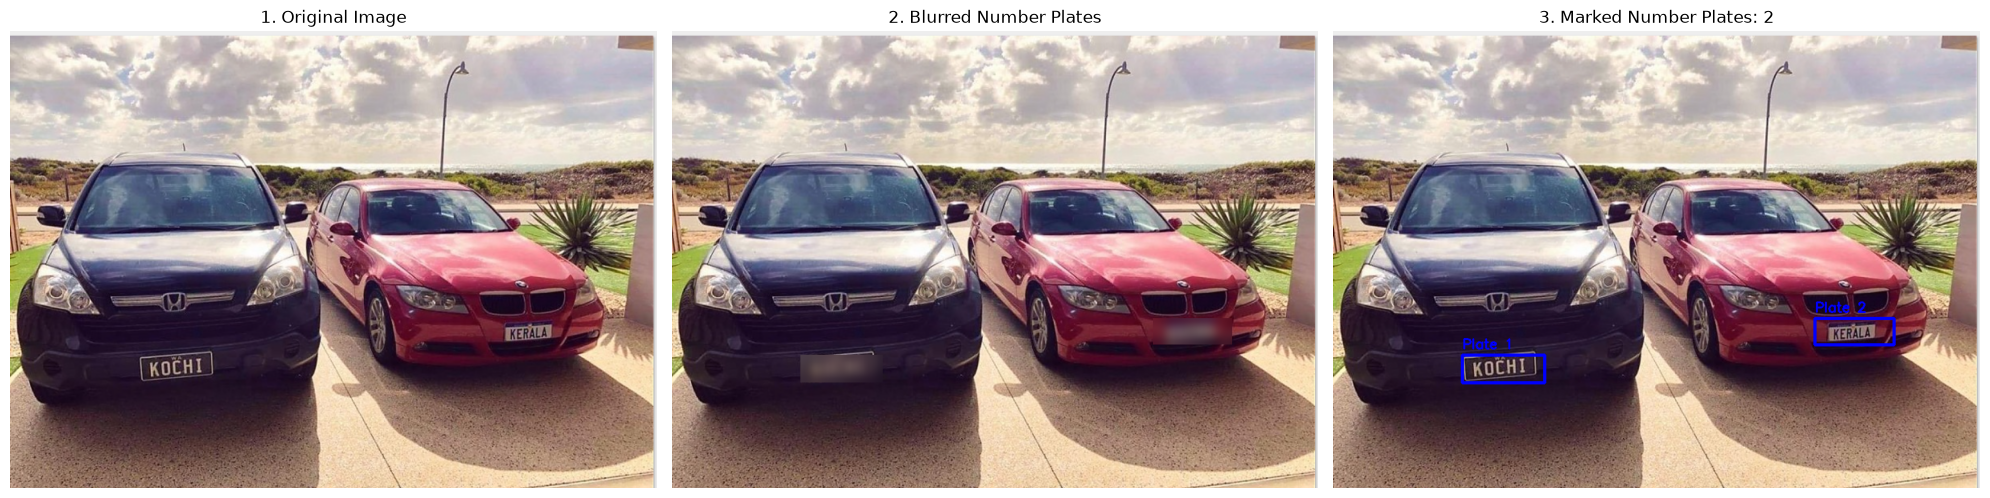

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("car.png")

if img is None:
    raise Exception("Image not found")
original = img.copy()

cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_russian_plate_number.xml"
)

if cascade.empty():
    raise Exception("Cascade file not found")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = cv2.equalizeHist(gray)


detections = cascade.detectMultiScale(
    gray,
    scaleFactor=1.03,
    minNeighbors=5,
    minSize=(50, 15),
    maxSize=(300, 100)
)

print("Detected:", len(detections))

plates = []

H, W = gray.shape

for (x, y, w, h) in detections:
    ratio = w / float(h)
    # Plate should be horizontal
    if ratio < 2.2 or ratio > 5.5:
        continue
    # Ignore small detections
    if w < 50 or h < 15:
        continue
    # Ignore upper part
    if y < int(H * 0.45):
        continue
    plates.append((x, y, w, h))
final_plates = []

for plate in plates:
    x, y, w, h = plate
    keep = True
    for old in final_plates:
        ox, oy, ow, oh = old
        x_left = max(x, ox)
        y_top = max(y, oy)
        x_right = min(x + w, ox + ow)
        y_bottom = min(y + h, oy + oh)
        if x_right > x_left and y_bottom > y_top:
            intersection = (
                (x_right - x_left) *
                (y_bottom - y_top)
            )
            area = min(w * h, ow * oh)

            if intersection / area > 0.4:
                keep = False
                break

    if keep:
        final_plates.append(plate)


print("Final plates:", len(final_plates))
marked = img.copy()

for i, (x, y, w, h) in enumerate(final_plates):

    # BLUE rectangle
    cv2.rectangle(
        marked,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        4
    )

    # Plate label
    cv2.putText(
        marked,
        "Plate " + str(i + 1),
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

blurred = img.copy()

for (x, y, w, h) in final_plates:

    # Extract plate
    plate = blurred[y:y+h, x:x+w]

    # Apply Gaussian blur
    blurred_plate = cv2.GaussianBlur(
        plate,
        (51, 51),
        0
    )

    # Put blurred plate back
    blurred[y:y+h, x:x+w] = blurred_plate


original_rgb = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

blurred_rgb = cv2.cvtColor(
    blurred,
    cv2.COLOR_BGR2RGB
)

marked_rgb = cv2.cvtColor(
    marked,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(20, 8))
plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title("1. Original Image")
plt.axis("off")


plt.subplot(1, 3, 2)
plt.imshow(blurred_rgb)
plt.title("2. Blurred Number Plates")
plt.axis("off")


plt.subplot(1, 3, 3)
plt.imshow(marked_rgb)
plt.title(
    "3. Marked Number Plates: "
    + str(len(final_plates))
)
plt.axis("off")
plt.tight_layout()
plt.show()